# Olist Seller Enablement Warehouse Analysis

This notebook is the analytical source for the final project story. It uses the dbt-built DuckDB warehouse and marts to translate public Olist marketplace transactions into a seller-enablement decision view.

Important interpretation: Product GMV is item price only, while GTV is item price plus freight. They are marketplace-channel activity signals, not confirmed Olist revenue, because the public dataset does not include take rates, SaaS fees, logistics margin, financial services revenue, or operating costs.


In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
WAREHOUSE_PATH = PROJECT_ROOT / "data" / "warehouse" / "module2_project.duckdb"

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.2f}".format

con = duckdb.connect(str(WAREHOUSE_PATH), read_only=True)


## 1. Warehouse And Pipeline Readiness

The modernized pipeline now loads raw CSV files into DuckDB, builds warehouse tables and decision marts with dbt, validates the model with dbt and SQL quality checks, and exposes the marts to Streamlit and Dagster.


In [2]:
table_counts = con.execute("""
    SELECT schema_name, table_name, estimated_size AS rows
    FROM duckdb_tables()
    WHERE schema_name IN ('raw', 'warehouse')
    ORDER BY schema_name, table_name
""").df()
table_counts


,schema_name,table_name,rows
0,raw,raw_customers,99441
1,raw,raw_geolocation,1000163
2,raw,raw_order_items,112650
3,raw,raw_order_payments,103886
4,raw,raw_order_reviews,99224
5,raw,raw_orders,99441
6,raw,raw_product_category_name_translation,71
7,raw,raw_products,32951
8,raw,raw_sellers,3095
9,warehouse,dim_customer,99441


## 2. Executive KPI Snapshot

The key executive readout is platform activity and seller health, not retail revenue. Product GMV is item price only; GTV is item price plus freight; order payment value is kept at order grain to avoid double-counting multi-item orders.


In [3]:
overview = con.execute("SELECT * FROM warehouse.mart_platform_overview").df()
overview_t = overview.T.rename(columns={0: "value"})
overview_t


,value
orders,"98,666.00"
order_items,"112,650.00"
active_sellers,"3,095.00"
purchasing_customers,"98,666.00"
product_gmv,"13,591,643.70"
freight_value,"2,251,909.54"
gross_transaction_value,"15,843,553.24"
order_payment_value,"16,008,872.12"
product_gmv_per_seller,"4,391.48"
orders_per_seller,31.88


In [4]:
row = overview.iloc[0]
summary = pd.DataFrame({
    "Metric": [
        "Orders", "Active sellers", "Product GMV", "Gross transaction value",
        "Order payment value", "Product GMV per seller", "Average review", "Late delivery rate"
    ],
    "Value": [
        f"{row.orders:,.0f}", f"{row.active_sellers:,.0f}", f"${row.product_gmv:,.0f}",
        f"${row.gross_transaction_value:,.0f}", f"${row.order_payment_value:,.0f}",
        f"${row.product_gmv_per_seller:,.0f}", f"{row.avg_review_score:.2f}",
        f"{row.late_delivery_rate:.1%}"
    ]
})
summary


,Metric,Value
0,Orders,"98,666"
1,Active sellers,"3,095"
2,Product GMV,"$13,591,644"
3,Gross transaction value,"$15,843,553"
4,Order payment value,"$16,008,872"
5,Product GMV per seller,"$4,391"
6,Average review,4.03
7,Late delivery rate,6.6%


## 3. Growth Trend, With Partial Month Removed

The latest month in the source data is partial, so it is excluded from the trend charts. This avoids showing an artificial drop at the end of the series.


In [5]:
monthly = con.execute("""
    SELECT *
    FROM warehouse.mart_monthly_platform_health
    WHERE month_start < (SELECT max(month_start) FROM warehouse.mart_monthly_platform_health)
    ORDER BY month_start
""").df()
monthly.tail()


,month_start,orders,order_items,active_sellers,purchasing_customers,product_gmv,gross_transaction_value,product_gmv_per_seller,avg_review_score,avg_delivery_days,late_delivery_rate
18,2018-04-01,6934,7975,1123,6934,"996,647.75","1,159,698.04",887.49,4.08,11.25,0.04
19,2018-05-01,6853,7925,1115,6853,"996,517.68","1,149,781.82",893.74,4.13,11.24,0.06
20,2018-06-01,6160,7078,1175,6160,"865,124.31","1,022,677.11",736.28,4.19,9.04,0.01
21,2018-07-01,6273,7092,1261,6273,"895,507.22","1,058,728.03",710.16,4.23,8.81,0.03
22,2018-08-01,6452,7248,1278,6452,"854,686.33","1,003,308.47",668.77,4.22,7.62,0.06


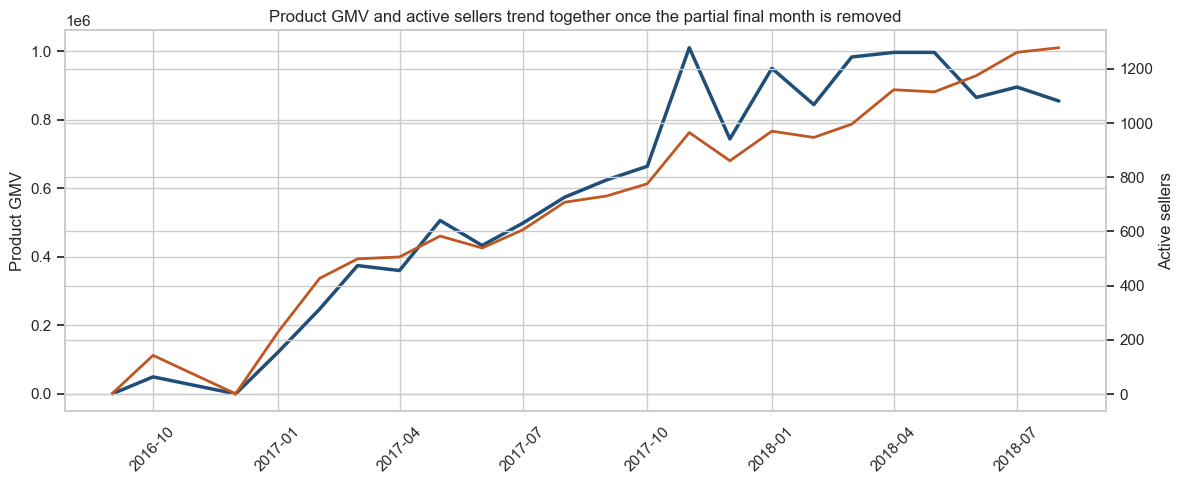

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly["month_start"], monthly["product_gmv"], color="#1f4e79", linewidth=2.5, label="Product GMV")
ax1.set_ylabel("Product GMV")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(monthly["month_start"], monthly["active_sellers"], color="#c05621", linewidth=2.0, label="Active sellers")
ax2.set_ylabel("Active sellers")
ax1.set_title("Product GMV and active sellers trend together once the partial final month is removed")
fig.tight_layout()
plt.show()


## 4. Seller Health Segmentation

Seller Health converts transaction data into account-management decisions. Sellers are grouped into four action segments:

- **Protect:** high-Product GMV sellers that create platform dependency and account-management priority.
- **Grow:** healthy sellers with room to scale.
- **Fix experience:** sellers with weak review or delivery signals that can damage buyer experience and seller outcomes.
- **Activate:** one-month sellers that need repeat-selling support.


In [7]:
seller_segments = con.execute("""
    SELECT
        seller_action_segment,
        count(*) AS sellers,
        sum(product_gmv) AS product_gmv,
        avg(avg_review_score) AS avg_review_score,
        avg(late_delivery_rate) AS late_delivery_rate
    FROM warehouse.mart_seller_health
    GROUP BY seller_action_segment
    ORDER BY product_gmv DESC
""").df()
seller_segments


,seller_action_segment,sellers,product_gmv,avg_review_score,late_delivery_rate
0,protect,310,"9,183,174.76",4.02,0.07
1,grow,1615,"3,592,575.30",4.30,0.04
2,fix experience,670,"645,679.96",2.58,0.23
3,activate,500,"170,213.68",4.75,0.00


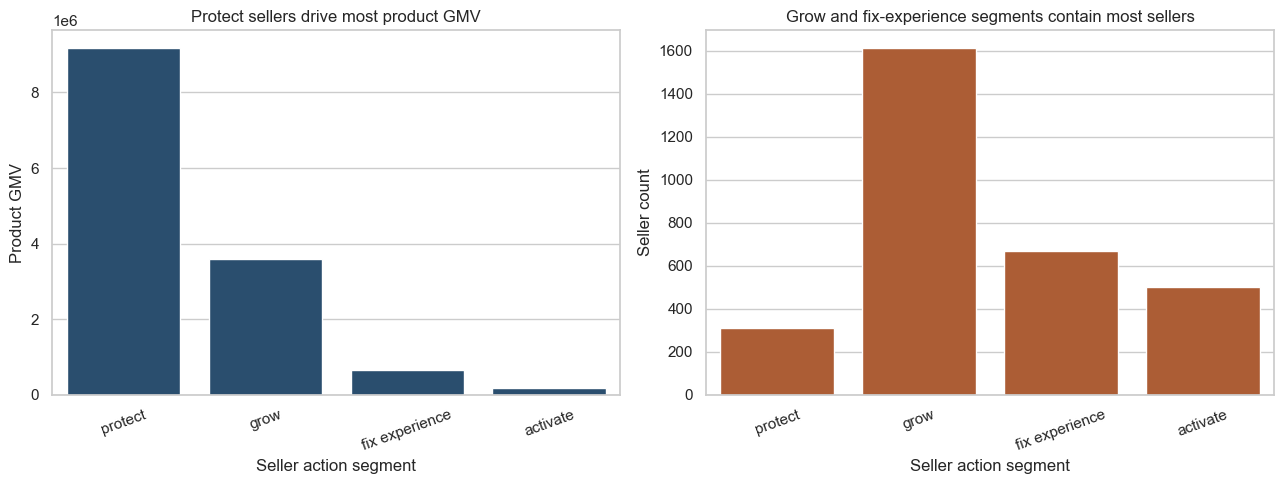

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=seller_segments, x="seller_action_segment", y="product_gmv", ax=axes[0], color="#1f4e79")
axes[0].set_title("Protect sellers drive most product GMV")
axes[0].set_xlabel("Seller action segment")
axes[0].set_ylabel("Product GMV")
axes[0].tick_params(axis="x", rotation=20)
sns.barplot(data=seller_segments, x="seller_action_segment", y="sellers", ax=axes[1], color="#c05621")
axes[1].set_title("Grow and fix-experience segments contain most sellers")
axes[1].set_xlabel("Seller action segment")
axes[1].set_ylabel("Seller count")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()


## 5. Seller Concentration Risk

A seller-enablement platform needs high-performing sellers, but concentration creates dependency risk. The concentration mart ranks sellers by product GMV and calculates cumulative share.


In [9]:
concentration = con.execute("""
    SELECT seller_rank, product_gmv, cumulative_product_gmv_share
    FROM warehouse.mart_seller_concentration
    WHERE seller_rank IN (10, 100, 500)
    ORDER BY seller_rank
""").df()
concentration


,seller_rank,product_gmv,cumulative_product_gmv_share
0,10,"135,171.70",0.13
1,100,"25,108.09",0.45
2,500,"6,109.44",0.78


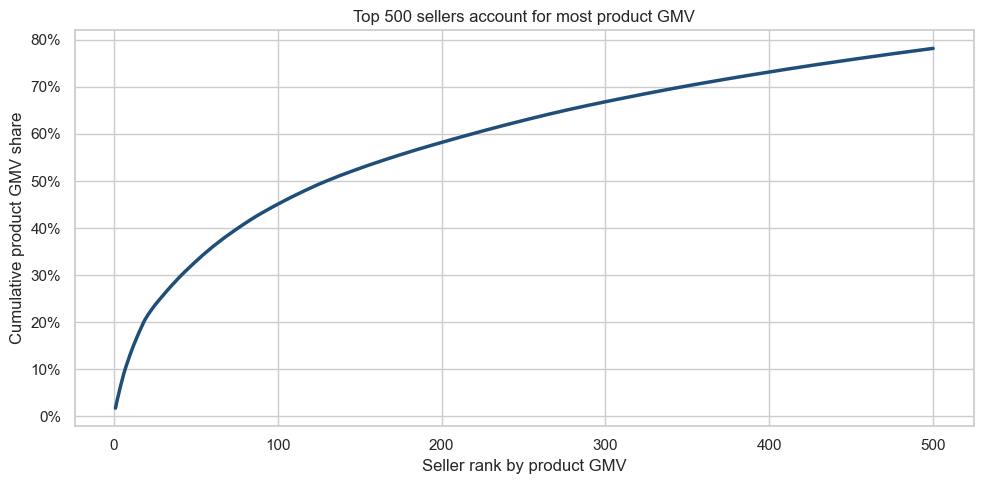

In [10]:
curve = con.execute("""
    SELECT seller_rank, cumulative_product_gmv_share
    FROM warehouse.mart_seller_concentration
    WHERE seller_rank <= 500
    ORDER BY seller_rank
""").df()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curve["seller_rank"], curve["cumulative_product_gmv_share"], color="#1f4e79", linewidth=2.5)
ax.set_title("Top 500 sellers account for most product GMV")
ax.set_xlabel("Seller rank by product GMV")
ax.set_ylabel("Cumulative product GMV share")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
fig.tight_layout()
plt.show()


## 6. Category Opportunity

Category opportunity combines demand, seller supply, and experience quality. The best categories are not only large; they also provide enough seller-side productivity to justify enablement focus.


In [11]:
categories = con.execute("""
    SELECT product_category, orders, active_sellers, product_gmv,
           product_gmv_per_seller, avg_review_score, late_delivery_rate
    FROM warehouse.mart_category_opportunity
    ORDER BY product_gmv DESC
    LIMIT 10
""").df()
categories


,product_category,orders,active_sellers,product_gmv,product_gmv_per_seller,avg_review_score,late_delivery_rate
0,health_beauty,8836,492,"1,258,681.34","2,558.30",4.14,0.08
1,watches_gifts,5624,101,"1,205,005.68","11,930.75",4.02,0.07
2,bed_bath_table,9417,196,"1,036,988.68","5,290.76",3.90,0.07
3,sports_leisure,7720,481,"988,048.97","2,054.16",4.11,0.06
4,computers_accessories,6689,287,"911,954.32","3,177.54",3.93,0.06
5,furniture_decor,6449,370,"729,762.49","1,972.33",3.91,0.07
6,cool_stuff,3632,267,"635,290.85","2,379.37",4.15,0.06
7,housewares,5884,468,"632,248.66","1,350.96",4.05,0.05
8,auto,3897,383,"592,720.11","1,547.57",4.06,0.07
9,garden_tools,3518,237,"485,256.46","2,047.50",4.05,0.07


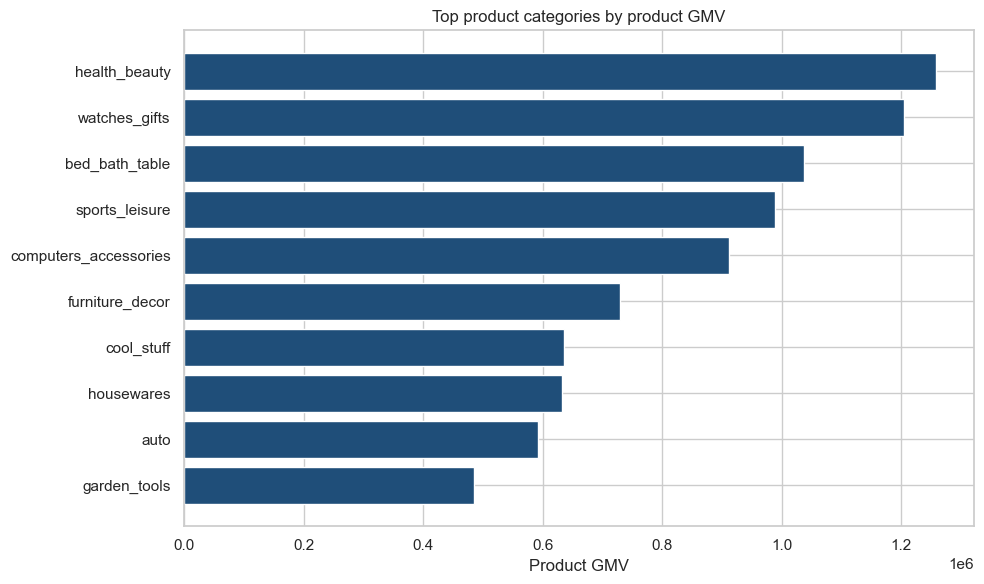

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_categories = categories.sort_values("product_gmv", ascending=True)
ax.barh(plot_categories["product_category"], plot_categories["product_gmv"], color="#1f4e79")
ax.set_title("Top product categories by product GMV")
ax.set_xlabel("Product GMV")
ax.set_ylabel("")
fig.tight_layout()
plt.show()


## 7. Regional Fulfillment Friction

Regional views show where seller success may be constrained by logistics. High-demand states define the commercial base; slow-delivery states highlight corridors where Olist could protect reviews and seller retention.


In [13]:
regional = con.execute("""
    SELECT
        customer_state,
        sum(orders) AS orders,
        sum(product_gmv) AS product_gmv,
        avg(avg_delivery_days) AS avg_delivery_days,
        avg(late_delivery_rate) AS late_delivery_rate
    FROM warehouse.mart_regional_fulfillment
    GROUP BY customer_state
    ORDER BY product_gmv DESC
    LIMIT 10
""").df()
regional


,customer_state,orders,product_gmv,avg_delivery_days,late_delivery_rate
0,SP,"41,593.00","5,202,955.05",12.02,0.03
1,RJ,"12,827.00","1,824,092.67",14.85,0.07
2,MG,"11,614.00","1,585,308.03",12.43,0.02
3,RS,"5,472.00","750,304.02",16.08,0.07
4,PR,"5,024.00","683,083.76",12.65,0.05
5,SC,"3,629.00","520,553.34",16.80,0.06
6,BA,"3,369.00","511,349.99",17.75,0.11
7,DF,"2,137.00","302,603.94",12.53,0.04
8,GO,"2,014.00","294,591.95",13.76,0.03
9,ES,"2,038.00","275,037.31",16.74,0.08


In [14]:
friction = con.execute("""
    SELECT
        customer_state,
        sum(orders) AS orders,
        sum(product_gmv) AS product_gmv,
        avg(avg_delivery_days) AS avg_delivery_days,
        avg(late_delivery_rate) AS late_delivery_rate
    FROM warehouse.mart_regional_fulfillment
    GROUP BY customer_state
    HAVING sum(orders) >= 100
    ORDER BY avg_delivery_days DESC
    LIMIT 10
""").df()
friction


,customer_state,orders,product_gmv,avg_delivery_days,late_delivery_rate
0,AM,147.00,"22,356.84",36.64,0.10
1,AL,412.00,"80,314.81",26.19,0.18
2,PA,974.00,"178,947.81",24.00,0.09
3,SE,346.00,"58,920.85",21.18,0.14
4,RO,247.00,"46,140.64",19.22,0.02
5,PB,535.00,"115,268.08",18.85,0.09
6,MA,747.00,"119,648.22",18.67,0.09
7,MT,910.00,"156,453.53",18.15,0.05
8,CE,"1,330.00","227,254.71",18.11,0.10
9,BA,"3,369.00","511,349.99",17.75,0.11


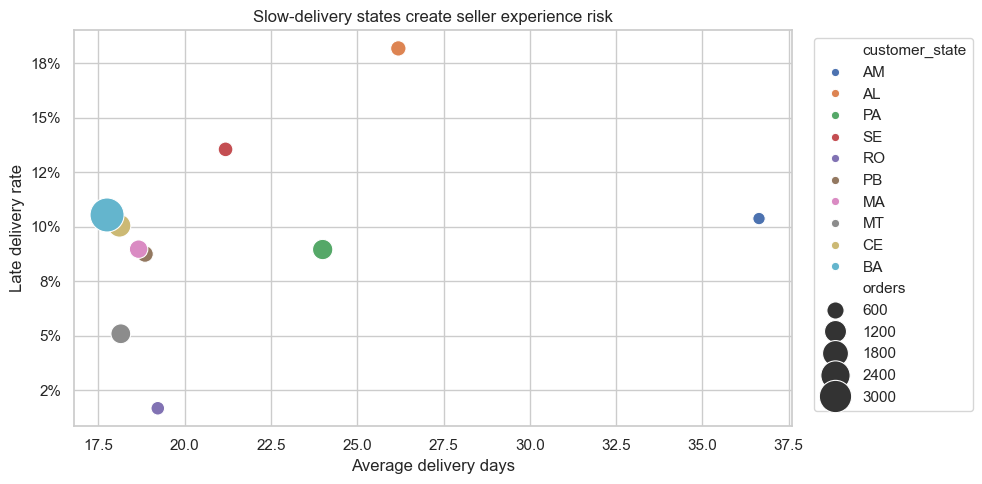

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=friction,
    x="avg_delivery_days",
    y="late_delivery_rate",
    size="orders",
    hue="customer_state",
    sizes=(80, 600),
    ax=ax,
)
ax.set_title("Slow-delivery states create seller experience risk")
ax.set_xlabel("Average delivery days")
ax.set_ylabel("Late delivery rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()


## 8. Recommendations

1. **Protect high-Product GMV sellers.** The top seller group drives a disproportionate share of GMV, so account support and early-warning monitoring should be explicit priorities.
2. **Scale healthy mid-tail sellers.** The grow segment has strong review and delivery signals; these sellers are good candidates for assortment expansion, marketplace education, and service upsell.
3. **Repair experience-risk sellers.** Low reviews and late delivery can damage marketplace trust. These sellers need operational coaching, logistics support, and stricter monitoring.
4. **Activate one-month sellers.** Many sellers appear only briefly. Olist should use onboarding, category guidance, and seller tools to convert first-month activity into repeat selling.
5. **Target category and regional plays.** Strong Product GMV categories and high-friction delivery corridors should guide where Olist invests seller support and logistics partnerships.
